In [1]:
import numpy as np

np.random.seed(42)

n_samples = 1000
n_features = 6
n_factors = 2

# True factor loadings
Lambda_true = np.array([
    [0.9, 0.1],
    [0.8, 0.2],
    [0.7, 0.3],
    [0.1, 0.8],
    [0.2, 0.9],
    [0.3, 0.7],
])

# Noise variances (unique variances)
psi = np.diag([0.1, 0.1, 0.2, 0.1, 0.1, 0.2])

# Latent factors
Z = np.random.randn(n_samples, n_factors)

# Observations
X = Z @ Lambda_true.T + np.random.multivariate_normal(
    mean=np.zeros(n_features),
    cov=psi,
    size=n_samples
)


In [2]:
from sklearn.decomposition import FactorAnalysis

fa = FactorAnalysis(n_components=2, random_state=42)
X_fa = fa.fit_transform(X)


In [3]:
print("Estimated factor loadings:")
print(np.round(fa.components_, 3))


Estimated factor loadings:
[[-0.655 -0.668 -0.695 -0.655 -0.786 -0.727]
 [-0.565 -0.436 -0.27   0.493  0.484  0.256]]


In [4]:
print("Estimated noise variances:")
print(np.round(fa.noise_variance_, 3))


Estimated noise variances:
[0.112 0.085 0.201 0.106 0.1   0.227]


In [5]:
print("True loadings:")
print(Lambda_true.T)


True loadings:
[[0.9 0.8 0.7 0.1 0.2 0.3]
 [0.1 0.2 0.3 0.8 0.9 0.7]]


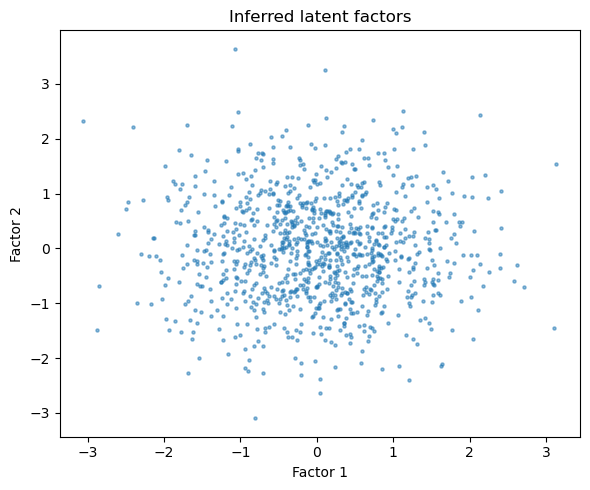

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.scatter(X_fa[:, 0], X_fa[:, 1], s=5, alpha=0.5)
plt.xlabel("Factor 1")
plt.ylabel("Factor 2")
plt.title("Inferred latent factors")
plt.tight_layout()
plt.show()


In [7]:
Sigma_true = Lambda_true @ Lambda_true.T + psi
Sigma_est = fa.components_.T @ fa.components_ + np.diag(fa.noise_variance_)

err = np.linalg.norm(Sigma_true - Sigma_est) / np.linalg.norm(Sigma_true)
print("Relative covariance error:", err)


Relative covariance error: 0.0515938309029258


In [8]:
from scipy.linalg import subspace_angles

angles = subspace_angles(Lambda_true, fa.components_.T)
print("Principal angles (degrees):", np.degrees(angles))


Principal angles (degrees): [1.47401685 0.80123663]


In [9]:
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import normalize

def varimax(Phi, gamma=1.0, q=20, tol=1e-6):
    p, k = Phi.shape
    R = np.eye(k)
    for _ in range(q):
        d = np.diag(Phi @ R)
        Lambda = Phi @ R
        u, s, vh = np.linalg.svd(
            Phi.T @ (Lambda**3 - (gamma/p) * Lambda @ np.diag(np.sum(Lambda**2, axis=0)))
        )
        R_new = u @ vh
        if np.max(np.abs(R - R_new)) < tol:
            break
        R = R_new
    return Phi @ R

Lambda_rot = varimax(fa.components_.T)
print(np.round(Lambda_rot, 2))


[[-0.11 -0.86]
 [-0.2  -0.77]
 [-0.33 -0.67]
 [-0.82 -0.07]
 [-0.91 -0.17]
 [-0.71 -0.3 ]]


In [10]:
Z_est = fa.transform(X)

corr = np.corrcoef(Z.T, Z_est.T)[:2, 2:]
print(np.round(corr, 2))


[[-0.67 -0.69]
 [-0.71  0.66]]


In [11]:
from scipy.linalg import orthogonal_procrustes

R, _ = orthogonal_procrustes(Z_est, Z)
Z_aligned = Z_est @ R

print(np.round(np.corrcoef(Z.T, Z_aligned.T)[:2, 2:], 2))


[[0.96 0.03]
 [0.03 0.97]]


In [12]:
import numpy as np

np.random.seed(42)

n_samples = 1000
n_features = 6
n_factors = 2

Lambda_true = np.array([
    [0.9, 0.1],
    [0.8, 0.2],
    [0.7, 0.3],
    [0.1, 0.8],
    [0.2, 0.9],
    [0.3, 0.7],
])

psi_true = np.diag([0.1, 0.1, 0.2, 0.1, 0.1, 0.2])

Z_true = np.random.randn(n_samples, n_factors)
X = Z_true @ Lambda_true.T + np.random.multivariate_normal(
    np.zeros(n_features), psi_true, size=n_samples
)


In [13]:
import pymc as pm
import pytensor.tensor as pt

with pm.Model() as bayes_fa:
    Lambda = pm.Normal("Lambda", 0, 1, shape=(n_features, n_factors))
    psi = pm.HalfNormal("psi", 1.0, shape=n_features)

    Z = pm.Normal("Z", 0, 1, shape=(n_samples, n_factors))

    mu = pt.dot(Z, Lambda.T)
    X_obs = pm.Normal("X_obs", mu=mu, sigma=pt.sqrt(psi), observed=X)

    trace_fa = pm.sample(1000, tune=1000, chains=2, target_accept=0.9)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [Lambda, psi, Z]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 14 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [15]:
import pymc as pm
import pytensor.tensor as pt

with pm.Model() as identified_fa:

    # unconstrained loadings
    Lambda_raw = pm.Normal("Lambda_raw", 0, 1, shape=(n_features, n_factors))

    # lower-triangular constraint
    Lambda = pt.set_subtensor(Lambda_raw[0, 1], 0.0)

    # positive diagonal (sign identification)
    Lambda = pt.set_subtensor(Lambda[0, 0], pt.abs(Lambda[0, 0]))
    Lambda = pt.set_subtensor(Lambda[1, 1], pt.abs(Lambda[1, 1]))

    Lambda = pm.Deterministic("Lambda", Lambda)

    psi = pm.HalfNormal("psi", 1.0, shape=n_features)
    Z = pm.Normal("Z", 0, 1, shape=(n_samples, n_factors))

    mu = pt.dot(Z, Lambda.T)

    X_obs = pm.Normal(
        "X_obs",
        mu=mu,
        sigma=pt.sqrt(psi),
        observed=X
    )

    trace_id = pm.sample(
        1000,
        tune=1000,
        chains=2,
        target_accept=0.9
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [Lambda_raw, psi, Z]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 27 seconds.
There were 36 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [16]:
from sklearn.decomposition import FactorAnalysis
from scipy.linalg import orthogonal_procrustes

fa = FactorAnalysis(n_components=2)
Z_est = fa.fit_transform(X)

R, _ = orthogonal_procrustes(Z_est, Z_true)
Z_aligned = Z_est @ R

print(np.round(np.corrcoef(Z_true.T, Z_aligned.T)[:2, 2:], 2))


[[0.96 0.03]
 [0.03 0.97]]
